# O Nordeste como Supridor do SIN: Visualizando Gargalos e Cenários Críticos da Intermitência Renovável (2024-2025)

---


#### Vitória Emanuele de Sousa Silva | contato: vitoriaemanueledesousa@gmail.com


---



**I. Escopo:** O projeto se insere no campo da operação e planejamento do setor elétrico, com foco em analisar os impactos da intermitência de energias renováveis (eólica e fotovoltaica) no subsistema Nordeste durante o biênio 2024-2025. A análise de dados foi utilizada para identificar gargalos operacionais e cenários críticos de estresse na rede, destacando o fenômeno da 'Curva do Pato' e a alta estocasticidade da geração eólica, oferecendo insights visuais para apoiar a tomada de decisão no despacho de energia e garantir a segurança do Sistema Interligado Nacional (SIN).

**II. Desafio:** O desafio enfrentado é a dificuldade em prever e manejar antecipadamente os momentos de instabilidade na rede elétrica, devido à alta penetração e intermitência das fontes renováveis no Nordeste. A ausência de uma visão clara sobre os gargalos operacionais, como o descompasso da 'Curva do Pato' (queda solar) e a alta volatilidade estocástica dos ventos, dificultava a tomada de decisões preventivas focadas no despacho seguro de energia. O projeto busca resolver este problema por meio de visualizações que destacam os cenários críticos de estresse e as janelas de vulnerabilidade do Sistema Interligado Nacional (SIN).

**III. Mapeamento dos dados e Visualização :**

In [144]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd
import numpy as np


Os datasets anuais do ONS (2024 e 2025) são carregados individualmente para permitir uma validação inicial de integridade.

In [145]:
df_2024 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2024.csv', sep=';')

# Create a DataFrame to display column information in a more structured way
column_info = pd.DataFrame({
    'Column Name': df_2024.columns,
    'Data Type': df_2024.dtypes,
    'Non-Null Count': df_2024.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,43920
1,nom_subsistema,str,43920
2,din_instante,str,43920
3,val_gerhidraulica,float64,43920
4,val_gertermica,float64,43920
5,val_gereolica,float64,43920
6,val_gersolar,float64,43920
7,val_carga,float64,43920
8,val_intercambio,float64,43920


In [146]:
df_2025 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2025.csv', sep=';')

column_info = pd.DataFrame({
    'Column Name': df_2025.columns,
    'Data Type': df_2025.dtypes,
    'Non-Null Count': df_2025.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,43800
1,nom_subsistema,str,43800
2,din_instante,str,43800
3,val_gerhidraulica,float64,43800
4,val_gertermica,float64,43800
5,val_gereolica,float64,43800
6,val_gersolar,float64,43800
7,val_carga,float64,43800
8,val_intercambio,float64,43800



### 1.2 Dicionário de Variáveis (Dataset ONS)

Para este estudo de caso, as colunas foram interpretadas conforme as definições técnicas do Operador Nacional do Sistema (ONS):

* **`din_instante`**: Representa a marca temporal (data e hora) do registro.

* **`val_gerhidraulica`**: Total de energia gerada por usinas hídricas no subsistema (em MWmed).

* **`val_gertermica`**: Energia gerada por fontes térmicas (fósseis ou biomassa). Geralmente usada como base ou backup do sistema.

* **`val_gereolica`**: Potência gerada a partir da força dos ventos, principal fonte de exportação do Nordeste.

* **`val_gersolar`**: Geração fotovoltaica. É a fonte que apresenta a maior variação cíclica (dia/noite) e define a "curva do pato".

* **`val_carga`**: Representa a demanda ou consumo de energia da região naquele instante. É a linha que o sistema precisa sempre "atender".

* **`val_intercambio`**: Saldo líquido de energia. Valores positivos indicam que o Nordeste está exportando excedente para outras regiões; valores negativos indicam importação para suprir a demanda local.



### 1.3 :

As bases de dados foram concatenadas em um único DataFrame unificado, garantindo a continuidade da série temporal. Utilizou-se o parâmetro `ignore_index=True` para reorganizar os índices e evitar duplicidades.

In [147]:
df = pd.concat([df_2024, df_2025], ignore_index=True)

column_info = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,87720
1,nom_subsistema,str,87720
2,din_instante,str,87720
3,val_gerhidraulica,float64,87720
4,val_gertermica,float64,87720
5,val_gereolica,float64,87720
6,val_gersolar,float64,87720
7,val_carga,float64,87720
8,val_intercambio,float64,87720


Conversão da coluna `din_instante` para o formato ***datetime***. Além disso, extrai as colunas de 'Ano' e 'Mês', facilitando filtros temporais e análises comparativas posteriores.

In [148]:
# Converte para datetime
df['din_instante'] = pd.to_datetime(df['din_instante'])

# Extrai ano e mês (Feature Engineering básica)
df['ano'] = df['din_instante'].dt.year
df['mes'] = df['din_instante'].dt.month

column_info = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,87720
1,nom_subsistema,str,87720
2,din_instante,datetime64[us],87720
3,val_gerhidraulica,float64,87720
4,val_gertermica,float64,87720
5,val_gereolica,float64,87720
6,val_gersolar,float64,87720
7,val_carga,float64,87720
8,val_intercambio,float64,87720
9,ano,int32,87720


In [170]:

# identidade Visual unica
PALETA = {
    'Hídrica': '#a5b1c2',  # Cinza azulado (Base estável)
    'Térmica': '#778ca3',  # Cinza escuro (Backup)
    'Eólica':  '#26de81',  # Verde (Limpa/Vento)
    'Solar':   '#fed330',  # Amarelo/Laranja (Sol)
    'Demanda': '#2d3436',  # Grafite (Carga)
    'Pato':    '#eb4d4b',  # Vermelho suave (Estresse)
    'Destaque': '#20bf6b', # Verde Nordeste
    'Neutro':  '#d1d8e0'   # Cinza para outras regiões
}

def aplicar_estilo_limpo(ax, remover_eixo_x=False):
    sns.despine(ax=ax, left=True, bottom=False) 
    ax.tick_params(left=False, bottom=True)
    ax.grid(axis='y', linestyle='--', alpha=0.3) 
    if remover_eixo_x:
        ax.set_xlabel('')

1.4 : Matriz energetica Brasileira:

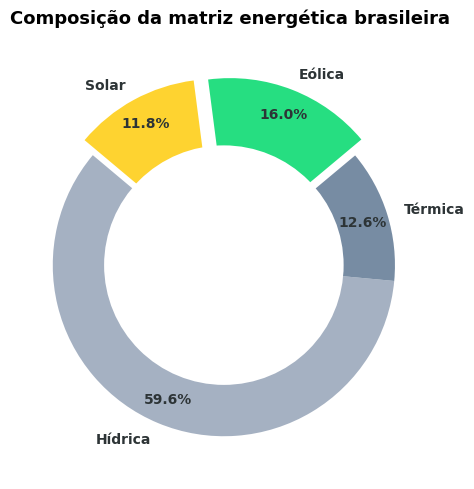

In [172]:
fontes_map = {'val_gerhidraulica': 'Hídrica', 'val_gertermica': 'Térmica', 
              'val_gereolica': 'Eólica', 'val_gersolar': 'Solar'}
valores = df[list(fontes_map.keys())].mean()
labels = [fontes_map[k] for k in valores.index]
cores_pizza = [PALETA[l] for l in labels]

fig, ax = plt.subplots(figsize=(7, 5))
explode = (0, 0, 0.1, 0.1) 

wedges, texts, autotexts = ax.pie(valores, labels=labels, autopct='%1.1f%%', 
                                  startangle=140, explode=explode, colors=cores_pizza, 
                                  pctdistance=0.85, textprops={'color':"#2d3436", 'weight':'bold'})

ax.add_artist(plt.Circle((0,0), 0.70, fc='white'))

plt.title('Composição da matriz energética brasileira', 
          fontsize=13, weight='bold', loc='left', pad=20)
plt.tight_layout()
plt.show()

1.5 Substistemas e geração de energia limpa:

C:\Users\Vitoria\AppData\Local\Temp\ipykernel_18340\913021439.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='geracao_limpa', y='nom_subsistema', data=ranking, palette=cores_reg, ax=ax)


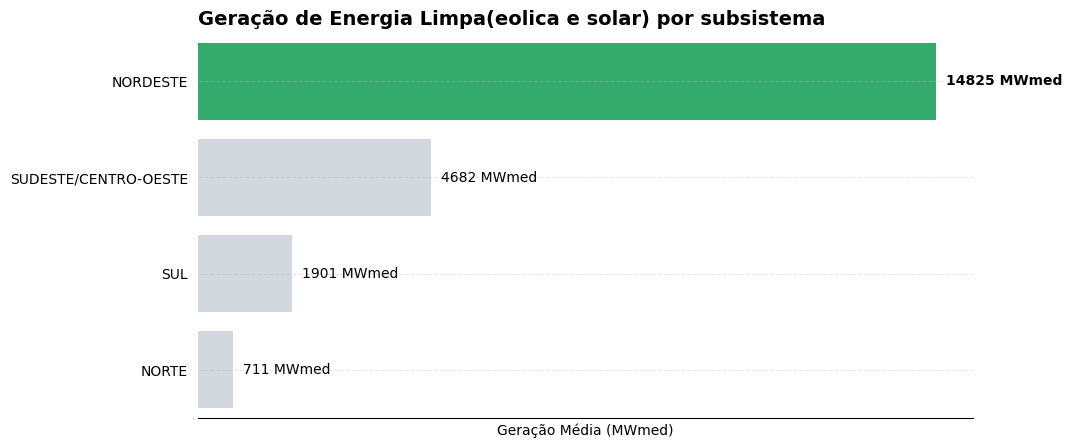

In [192]:
df_regioes = df[df['id_subsistema'] != 'SIN'].copy()
df_regioes['geracao_limpa'] = df_regioes['val_gereolica'] + df_regioes['val_gersolar']
ranking = df_regioes.groupby('nom_subsistema')['geracao_limpa'].mean().sort_values(ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
cores_reg = [PALETA['Destaque'] if r == 'NORDESTE' else PALETA['Neutro'] for r in ranking['nom_subsistema']]

sns.barplot(x='geracao_limpa', y='nom_subsistema', data=ranking, palette=cores_reg, ax=ax)

for i, valor in enumerate(ranking['geracao_limpa']):
    ax.text(valor + 200, i, f'{valor:.0f} MWmed', va='center', fontsize=10, 
            weight='bold' if ranking['nom_subsistema'][i] == 'NORDESTE' else 'normal')

aplicar_estilo_limpo(ax)
ax.set_xticks([]) 
plt.title('Geração de Energia Limpa(eolica e solar) por subsistema', fontsize=14, weight='bold', loc='left')
plt.xlabel('Geração Média (MWmed)')
plt.ylabel('')
plt.show()

In [178]:

df_ne = df[df['nom_subsistema'] == 'NORDESTE']

1.6 Geração e demanda de energia no Nordeste

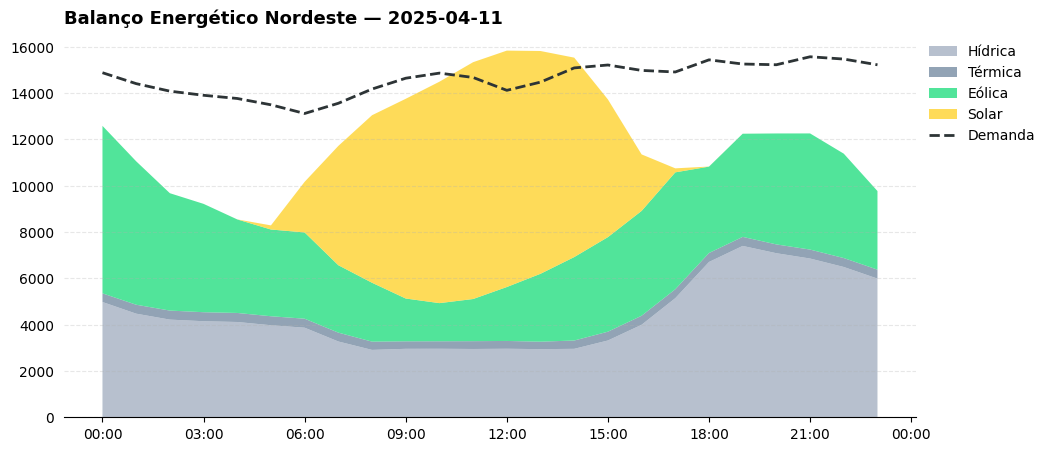

In [197]:
dia_analise = '2025-04-11' 
df_dia = df_ne[df_ne['din_instante'].dt.date == pd.to_datetime(dia_analise).date()].copy()

# Gráfico de Geração vs Demanda (Dia Normal)
fig, ax = plt.subplots(figsize=(11, 5))
labels_stack = ['Hídrica', 'Térmica', 'Eólica', 'Solar']
cores_stack = [PALETA[l] for l in labels_stack]

ax.stackplot(df_dia['din_instante'], df_dia['val_gerhidraulica'], df_dia['val_gertermica'],
             df_dia['val_gereolica'], df_dia['val_gersolar'],
             labels=labels_stack, colors=cores_stack, alpha=0.8, edgecolors='none')

ax.plot(df_dia['din_instante'], df_dia['val_carga'], label='Demanda', 
        color=PALETA['Demanda'], linestyle='--', linewidth=2)

aplicar_estilo_limpo(ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.title(f'Balanço Energético Nordeste — {dia_analise}', fontsize=13, weight='bold', loc='left')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
plt.show()

1.7 Fenomeno da Curva do Pato

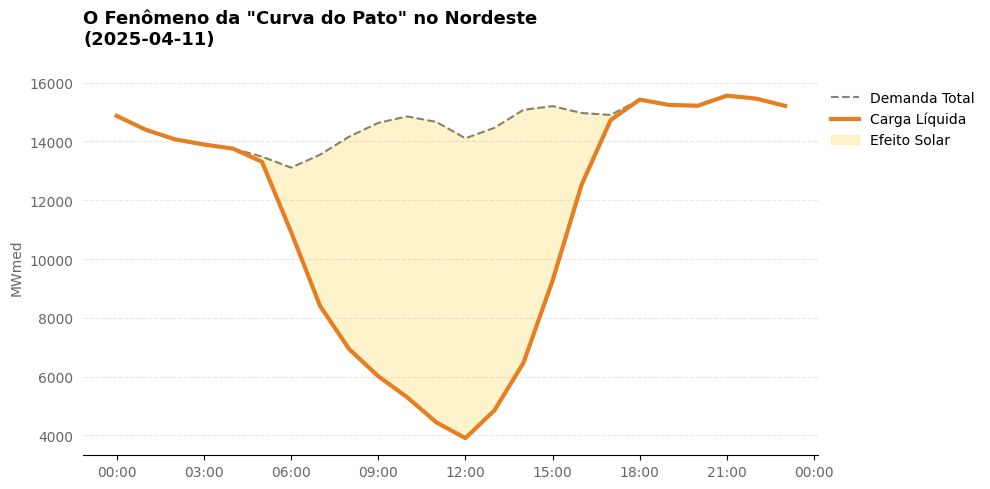

In [207]:

plt.figure(figsize=(10, 5))

plt.plot(df_dia['din_instante'], df_dia['val_carga'], 
         label='Demanda Total', color='#333333', linestyle='--', linewidth=1.5, alpha=0.6)


plt.plot(df_dia['din_instante'], df_dia['carga_liquida'], 
         label='Carga Líquida', color='#e67e22', linewidth=3)


plt.fill_between(df_dia['din_instante'], df_dia['carga_liquida'], df_dia['val_carga'], 
                 color=PALETA['Solar'], alpha=0.25, label='Efeito Solar')

aplicar_estilo_limpo(plt.gca()) 
plt.grid(axis='y', linestyle='--', alpha=0.3) 


plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(color='#666666')
plt.yticks(color='#666666')
plt.ylabel('MWmed', fontsize=10, color='#666666')


plt.title(f'O Fenômeno da "Curva do Pato" no Nordeste\n({dia_analise})', 
          fontsize=13, weight='bold', loc='left', pad=25)


plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

1.8 Volatilidade do vento no Nordeste

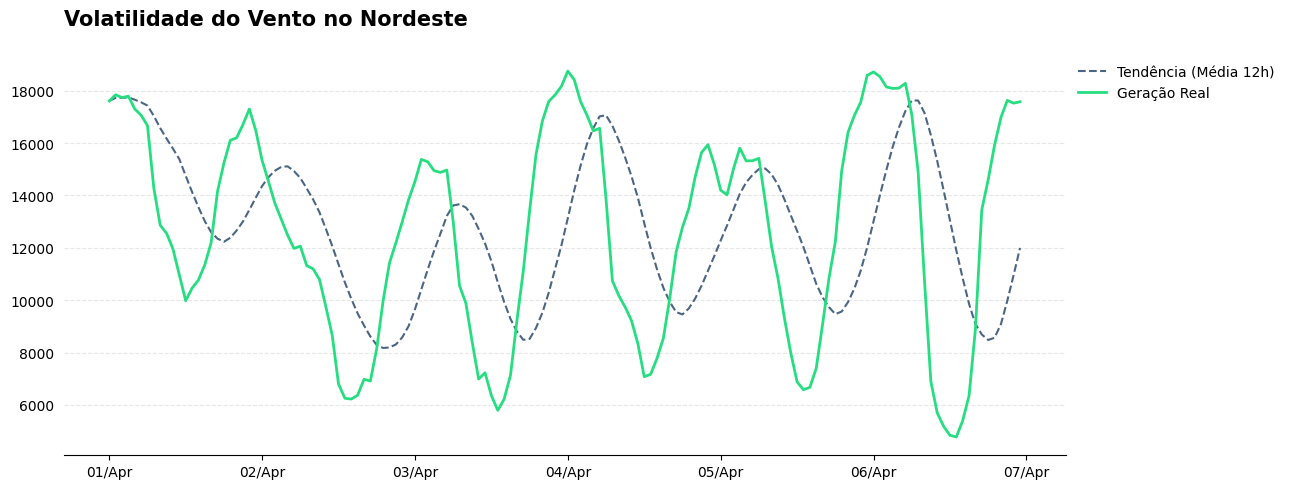

In [196]:
data_inicio = '2025-04-01'
data_fim = '2025-04-06'

df_semana = df_ne[(df_ne['din_instante'].dt.date >= pd.to_datetime(data_inicio).date()) & 
                  (df_ne['din_instante'].dt.date <= pd.to_datetime(data_fim).date())].copy()

df_semana['tendencia'] = df_semana['val_gereolica'].rolling(window=12, min_periods=1).mean()
tempo = df_semana['din_instante']

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(tempo, df_semana['tendencia'], color='#4b6584', linestyle='--', 
        linewidth=1.5, label='Tendência (Média 12h)')
ax.plot(tempo, df_semana['val_gereolica'], color=PALETA['Eólica'], 
        linewidth=2, label='Geração Real')

aplicar_estilo_limpo(ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%b'))

plt.title('Volatilidade do Vento no Nordeste', fontsize=15, weight='bold', loc='left', pad=20)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=10)

plt.tight_layout()
plt.show()